# Tutorial 5 - Null hypothesis testing and power
Main question:
Is the Biotechnology startup probability different between two countries?

The tutorial separates:
1. General concepts and observed effect size
2. Bayesian model-based comparison using a hierarchical model
3. Bayesian hypothesis testing using ROPE and HDI
4. Savage-Dickey / Bayes factor
5. Frequentist two-proportion z test
6. Frequentist confidence interval
7. Power
8. Final summary

## Setup

In [2]:
# Install Preliz only if it cannot be imported correctly

import subprocess
import sys

try:
    import preliz as pz
    print("preliz is already installed and working.")
except ModuleNotFoundError as error:
    print(f"preliz import failed because a dependency is missing: {error.name}")
    print("Installing/upgrading preliz and required dependencies...")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "preliz",
        "arviz-base",
        "arviz-stats"
    ])

    import preliz as pz
    print("preliz installed and imported successfully.")



preliz import failed because a dependency is missing: preliz
Installing/upgrading preliz and required dependencies...
preliz installed and imported successfully.


In [3]:
from pathlib import Path

import xarray as xr
import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import files

In [4]:
import scipy.stats as stats

In [5]:
az.style.use("arviz-darkgrid")
sns.set_style("darkgrid")

In [6]:
random_seed = 17

HDI_MASS = 0.94
SIGNIFICANCE_ALPHA = 0.05

BAYESIAN_COLOR = "tab:blue"
ROPE_COLOR = "tab:green"
NULL_COLOR = "black"
FREQUENTIST_COLOR = "tab:red"

In [7]:
# We use the larger startup dataset.
# If the file already exists in the Colab session, we read it directly.
# If not, we ask the user to upload it.


DATA_FILENAME = "big_startup_success_dataset"

# Possible file names in case the uploaded file has an extension
possible_filenames = [
    DATA_FILENAME,
    DATA_FILENAME + ".csv",
    DATA_FILENAME + ".txt",
    DATA_FILENAME + ".tsv",
]

existing_file = None

for fname in possible_filenames:
    if Path(fname).exists():
        existing_file = fname
        break

if existing_file is None:
    print("Data file was not found in the current Colab files.")
    print("Please upload the startup dataset.")

    uploaded = files.upload()

    # Take the uploaded file name
    existing_file = list(uploaded.keys())[0]
else:
    print(f"Using existing file: {existing_file}")

# Read the data
# The file looks tab-separated from the example you sent.
# sep=None lets pandas infer the separator.
df = pd.read_csv(existing_file, sep=None, engine="python")

df.head()

Data file was not found in the current Colab files.
Please upload the startup dataset.


Saving big_startup_success_dataset.csv to big_startup_success_dataset.csv


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/allone,Allone,http://www.alloneapp.com,Android|Application Platforms|Security,220000,closed,SWE,27,SWE - Other,Ängelholms Havsbad,1.0,15/03/2015,01/04/2015,01/04/2015
1,/organization/irezq,iRezQ,http://www.iRezQ.com,Mobile|Mobile Emergency&Health|SEO,150000,operating,SWE,27,SWE - Other,Åkarp,1.0,04/07/2012,20/03/2013,20/03/2013
2,/organization/ucommerce,uCommerce,http://www.ucommerce.net/,E-Commerce Platforms,597642,operating,DNK,18,DNK - Other,Århus,2.0,01/01/2008,03/04/2013,21/11/2014
3,/organization/bee-networx-astilbe,Bee Networx (Astilbe),http://www.beenetworx.com,Big Data|Media|Software,500000,operating,TUR,17,Ã‡an,Çan,1.0,NaN,26/02/2009,26/02/2009
4,/organization/beyond-the-rack,Beyond the Rack,http://www.beyondtherack.com,Fashion,98600000,operating,TUR,17,Ã‡an,Çan,7.0,01/01/2009,28/01/2010,01/10/2014


In [8]:
## Create Biotechnology variable

required_columns = ["name", "category_list", "country_code"]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["category_list"] = df["category_list"].astype(str).str.strip()

df["biotech"] = (
    df["category_list"]
    .str.contains("Biotechnology", case=False, na=False)
    .astype(int)
)

display(df[["name", "category_list", "country_code", "biotech"]].head())

,name,category_list,country_code,biotech
0,Allone,Android|Application Platforms|Security,SWE,0
1,iRezQ,Mobile|Mobile Emergency&Health|SEO,SWE,0
2,uCommerce,E-Commerce Platforms,DNK,0
3,Bee Networx (Astilbe),Big Data|Media|Software,TUR,0
4,Beyond the Rack,Fashion,TUR,0


In [9]:
# Create country-level grouped data

df_country = df.dropna(subset=["country_code"]).copy()

df_country["country_code"] = df_country["country_code"].astype(str).str.strip()

country_data = (
    df_country
    .groupby("country_code")
    .agg(
        n_startups=("biotech", "size"),
        n_biotech=("biotech", "sum")
    )
    .reset_index()
)

country_data["observed_biotech_rate"] = (
    country_data["n_biotech"] / country_data["n_startups"]
)

country_data = (
    country_data
    .sort_values("n_startups", ascending=False)
    .reset_index(drop=True)
)

 # Keep countries with enough data

min_startups_per_country = 30

country_data_filtered = (
    country_data[country_data["n_startups"] >= min_startups_per_country]
    .copy()
    .reset_index(drop=True)
)

print(f"Number of countries before filtering: {len(country_data)}")
print(f"Number of countries after filtering: {len(country_data_filtered)}")

display(country_data_filtered.head(10))

Number of countries before filtering: 137
Number of countries after filtering: 59


,country_code,n_startups,n_biotech,observed_biotech_rate
0,USA,37601,3342,0.088881
1,GBR,3688,235,0.063720
2,CAN,1925,147,0.076364
3,IND,1596,22,0.013784
4,CHN,1544,47,0.030440
5,FRA,1135,70,0.061674
6,DEU,1082,84,0.077634
7,ISR,965,70,0.072539
8,ESP,746,37,0.049598
9,AUS,503,33,0.065606


In [10]:
# Prepare variables for PyMC

country_names = country_data_filtered["country_code"].to_numpy()

n_startups = country_data_filtered["n_startups"].to_numpy()
n_biotech = country_data_filtered["n_biotech"].to_numpy()
observed_rate = country_data_filtered["observed_biotech_rate"].to_numpy()

n_countries = len(country_names)

coords = {
    "country": country_names
}

print(f"Number of countries: {n_countries}")
print(f"Total startups in model: {n_startups.sum()}")
print(f"Total Biotechnology startups in model: {n_biotech.sum()}")
print(f"Overall observed Biotechnology rate: {n_biotech.sum() / n_startups.sum():.4f}")


Number of countries: 59
Total startups in model: 59008
Total Biotechnology startups in model: 4399
Overall observed Biotechnology rate: 0.0745


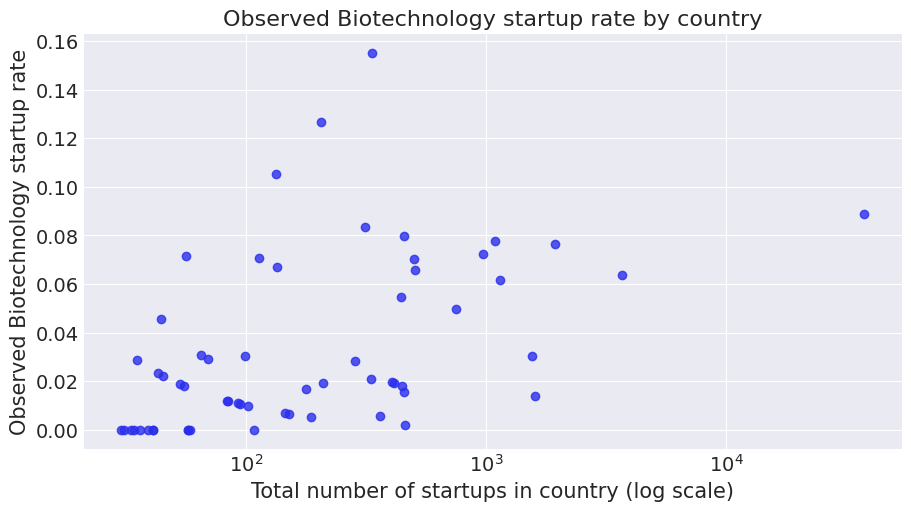

In [11]:
# Plot observed country rates

plt.figure(figsize=(9, 5))

plt.scatter(
    country_data_filtered["n_startups"],
    country_data_filtered["observed_biotech_rate"],
    alpha=0.8
)

plt.xscale("log")
plt.xlabel("Total number of startups in country (log scale)")
plt.ylabel("Observed Biotechnology startup rate")
plt.title("Observed Biotechnology startup rate by country")
plt.show()


#### Choose two countries for comparison


In [12]:
# You can change these two countries.
# Choose countries that are present in country_names and have enough startups.

country_A = "IND"
country_B = "CHN"


if country_A not in country_names:
    raise ValueError(f"{country_A} is not in the filtered country list.")

if country_B not in country_names:
    raise ValueError(f"{country_B} is not in the filtered country list.")

country_A_index = np.where(country_names == country_A)[0][0]
country_B_index = np.where(country_names == country_B)[0][0]

n_A = n_startups[country_A_index]
z_A = n_biotech[country_A_index]
rate_A = observed_rate[country_A_index]

n_B = n_startups[country_B_index]
z_B = n_biotech[country_B_index]
rate_B = observed_rate[country_B_index]

comparison_data = pd.DataFrame({
    "country": [country_A, country_B],
    "n_startups": [n_A, n_B],
    "n_biotech": [z_A, z_B],
    "observed_biotech_rate": [rate_A, rate_B],
})

display(comparison_data.style.format({
    "observed_biotech_rate": "{:.4f}"
}))


,country,n_startups,n_biotech,observed_biotech_rate
0,IND,1596,22,0.0138
1,CHN,1544,47,0.0304


,quantity,value
0,Observed rate A,0.0138
1,Observed rate B,0.0304
2,Observed difference A - B,-0.0167
3,Risk ratio A / B,0.4528
4,Odds ratio A / B,0.4452
5,Log odds ratio A / B,-0.8093
6,Cohen's h,-0.1154


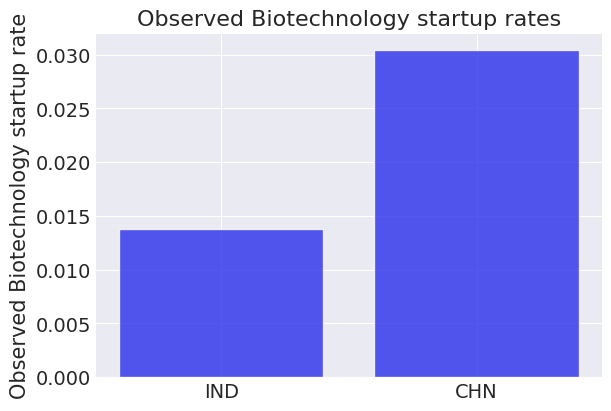

In [13]:
# Descriptive effect sizes

# Raw effect size: difference in observed Biotechnology rates
observed_difference = rate_A - rate_B

# Risk ratio
risk_ratio = rate_A / rate_B

# Odds ratio
odds_A = rate_A / (1 - rate_A)
odds_B = rate_B / (1 - rate_B)

odds_ratio = odds_A / odds_B
log_odds_ratio = np.log(odds_ratio)

# Cohen's h
# Normalized effect size for comparing proportions
cohens_h = (
    2 * np.arcsin(np.sqrt(rate_A))
    - 2 * np.arcsin(np.sqrt(rate_B))
)

effect_size_table = pd.DataFrame({
    "quantity": [
        "Observed rate A",
        "Observed rate B",
        "Observed difference A - B",
        "Risk ratio A / B",
        "Odds ratio A / B",
        "Log odds ratio A / B",
        "Cohen's h"
    ],
    "value": [
        rate_A,
        rate_B,
        observed_difference,
        risk_ratio,
        odds_ratio,
        log_odds_ratio,
        cohens_h
    ]
})

display(effect_size_table.style.format({"value": "{:.4f}"}))


plt.figure(figsize=(6, 4))

plt.bar(
    [country_A, country_B],
    [rate_A, rate_B],
    alpha=0.8
)

plt.ylabel("Observed Biotechnology startup rate")
plt.title("Observed Biotechnology startup rates")
plt.show()

## Bayesian Methods
Important modeling note:

The Bayesian comparison below uses a hierarchical model.
In this model, country parameters are not estimated independently.
They are connected through shared hyperparameters.

Therefore, the posterior difference between the two countries is the
difference after partial pooling / information sharing.

This is not the same as an independent frequentist two-sample test.
Both analyses are valid, but they answer different questions.

### Helper functions

In [14]:
# Helper function for predictive rate plots

def plot_predictive_rates(idata, group_name, n_trials, observed_rates, title):
    """
    Plot predictive rates from prior predictive or posterior predictive samples.

    The model predicts counts:
        z ~ Binomial(n, theta)

    We convert predictive counts to rates:
        predictive rate = predictive z / n
    """

    predictive_z = az.extract(
        idata,
        group=group_name,
        var_names="z"
    )

    predictive_rate = predictive_z / n_trials[:, None]

    plt.figure(figsize=(8, 5))

    plt.hist(
        predictive_rate.values.ravel(),
        bins=30,
        density=True,
        alpha=0.5,
        label="Predictive rates"
    )

    plt.hist(
        observed_rates,
        bins=30,
        density=True,
        histtype="step",
        linewidth=2,
        label="Observed rates"
    )

    plt.xlabel("Biotechnology startup rate")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()


### Prior

/usr/local/lib/python3.12/dist-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run XlogY0's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


omega_alpha = 2.880
omega_beta = 27.003
Prior mean = 0.096


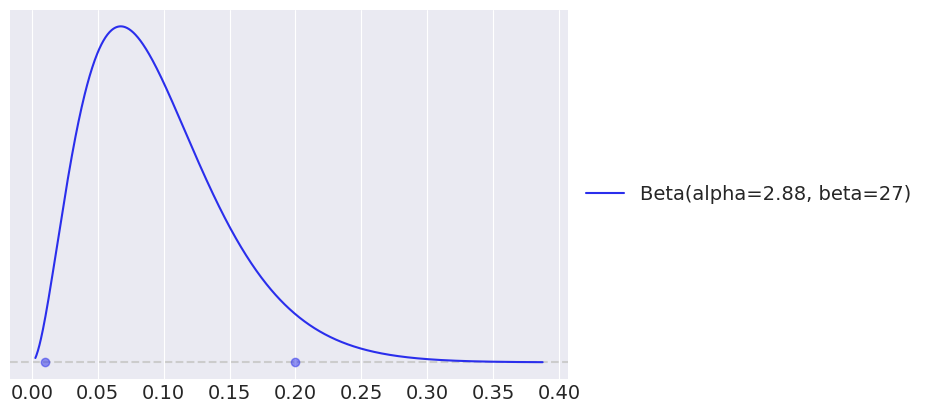

In [15]:
# Choose the prior

# Same prior logic as Tutorial 4:
# We expect the global Biotechnology startup rate to usually be between 1% and 20%.

biotech_rate_prior, ax = pz.maxent(
    pz.Beta(),
    lower=0.01,
    upper=0.20,
    mass=0.95,
    plot=True
)

omega_alpha = float(biotech_rate_prior.alpha)
omega_beta = float(biotech_rate_prior.beta)

print(f"omega_alpha = {omega_alpha:.3f}")
print(f"omega_beta = {omega_beta:.3f}")
print(f"Prior mean = {omega_alpha / (omega_alpha + omega_beta):.3f}")

### Model

In [16]:
# Hierarchical comparison model with pm.Deterministic
with pm.Model(coords=coords) as comparison_model:

    # Hyperpriors
    mu_theta = pm.Beta("mu_theta", alpha=omega_alpha, beta=omega_beta)
    nu_theta = pm.HalfNormal( "nu_theta", sigma=10)

    # Country-level parameters
    theta = pm.Beta("theta", mu=mu_theta, nu=nu_theta, dims="country")

    # Deterministic quantities of interest
    theta_A = pm.Deterministic("theta_A", theta[country_A_index])
    theta_B = pm.Deterministic("theta_B",theta[country_B_index])
    delta = pm.Deterministic("delta",theta_A - theta_B)

    # Likelihood
    z = pm.Binomial("z", n=n_startups, p=theta, observed=n_biotech, dims="country")


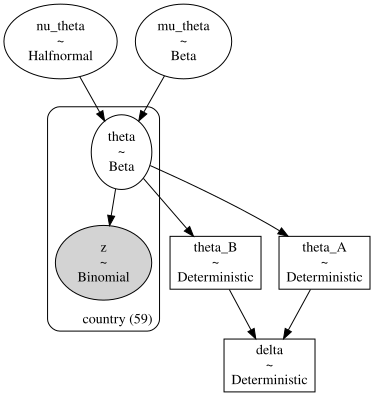

In [17]:
pm.model_to_graphviz(comparison_model)

###  Prior predictive check

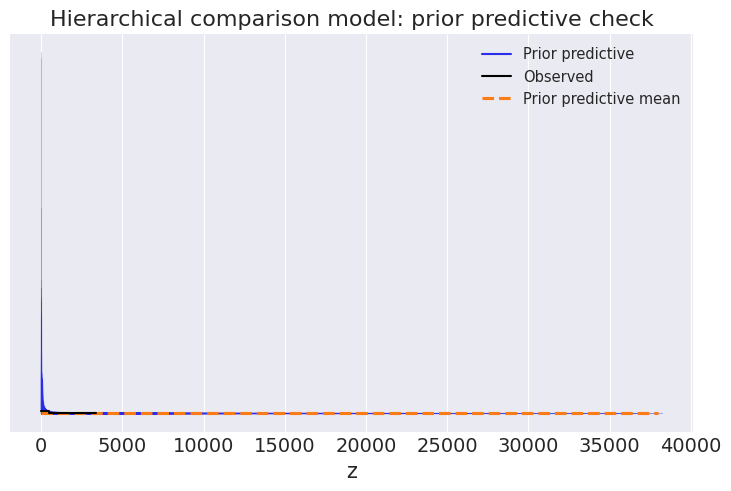

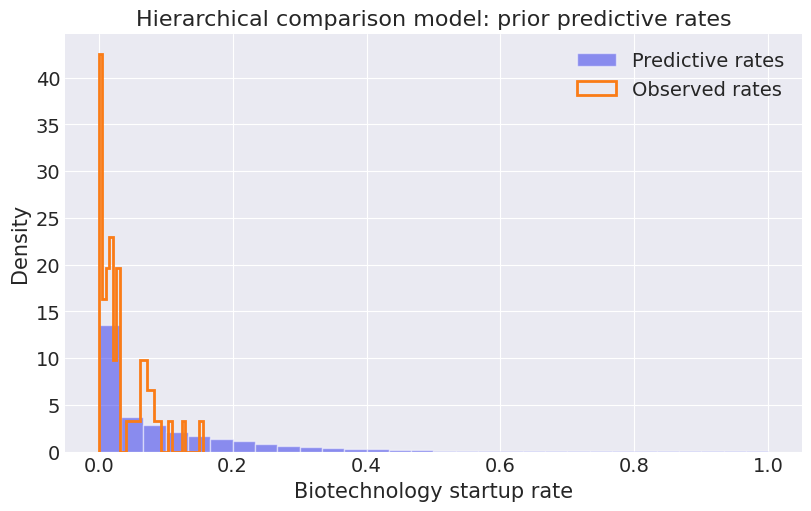

In [18]:
with comparison_model:
    idata_comparison_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_comparison_prior,
    group="prior",
    observed=True
)

plt.title("Hierarchical comparison model: prior predictive check")
plt.show()

plot_predictive_rates(
    idata=idata_comparison_prior,
    group_name="prior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Hierarchical comparison model: prior predictive rates"
)

### Sample posterior

In [19]:
with comparison_model:
    idata_comparison = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=random_seed) #  target_accept=0.95 if needed

# Add the prior group to the same InferenceData object.
# This is useful for Savage-Dickey / Bayes factor later.
idata_comparison.extend(idata_comparison_prior)

idata_comparison

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

### Diagnostics

/tmp/ipykernel_413/2572724016.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.8)


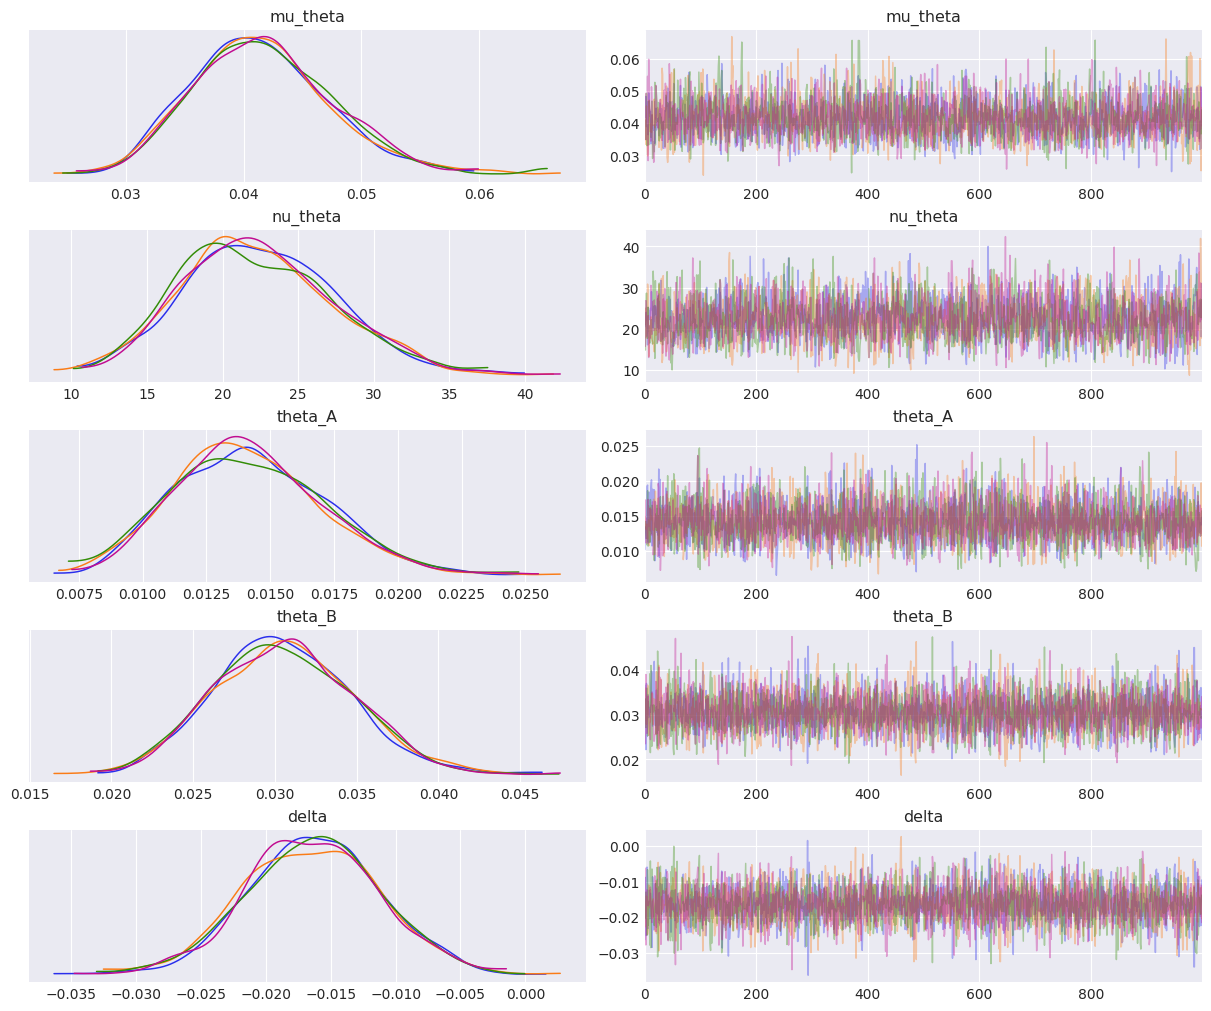

Number of divergences: 0


In [20]:
az.summary(
    idata_comparison,
    kind="diagnostics",
    var_names=["mu_theta", "nu_theta", "theta_A", "theta_B", "delta"]
)

az.plot_trace(
    idata_comparison,
    var_names=["mu_theta", "nu_theta", "theta_A", "theta_B", "delta"],
    compact=False
)

plt.subplots_adjust(hspace=0.8)
plt.show()

comparison_divergences = idata_comparison.sample_stats["diverging"].sum().values
print(f"Number of divergences: {comparison_divergences}")

# az.plot_pair(
#     idata_comparison,
#     var_names=["mu_theta", "nu_theta"],
#     kind="scatter",
#     divergences=True
# )

plt.show()

### Posterior predictive check

Output()

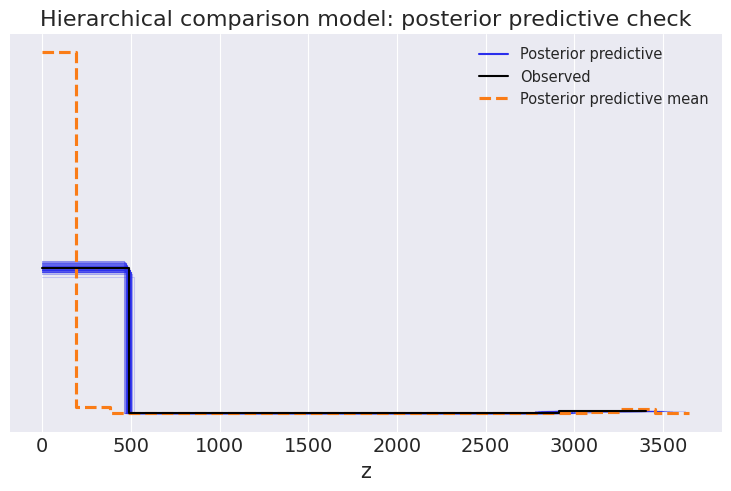

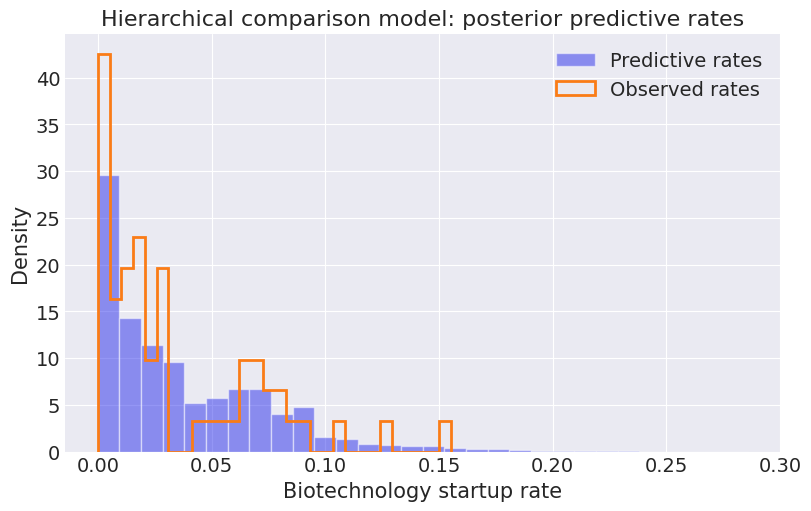

In [21]:
with comparison_model:
    idata_comparison = pm.sample_posterior_predictive(
        idata_comparison,
        var_names=["z"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_comparison,
    group="posterior",
    observed=True,
    num_pp_samples=100
)

plt.title("Hierarchical comparison model: posterior predictive check")
plt.show()


plot_predictive_rates(
    idata=idata_comparison,
    group_name="posterior_predictive",
    n_trials=n_startups,
    observed_rates=observed_rate,
    title="Hierarchical comparison model: posterior predictive rates"
)


### Posterior

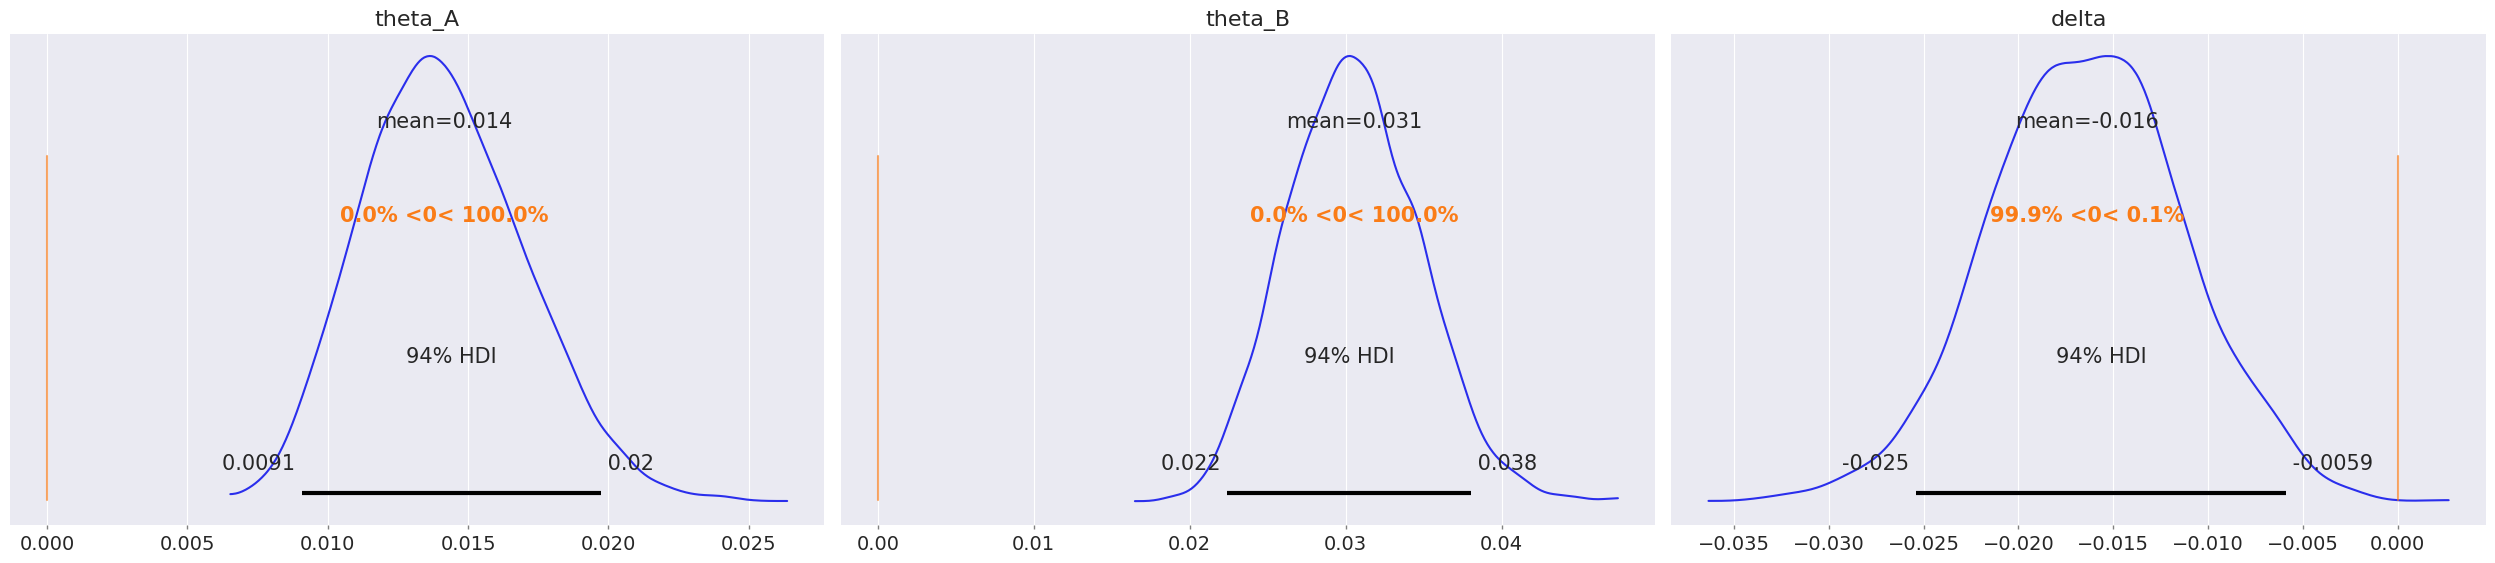

In [22]:
az.plot_posterior(
    idata_comparison,
    var_names=["theta_A", "theta_B", "delta"],
    ref_val=0)

plt.show()

## Bayesian posterior comparison

In [23]:
delta_samples = idata_comparison.posterior["delta"].values.ravel()
theta_A_samples = idata_comparison.posterior["theta_A"].values.ravel()
theta_B_samples = idata_comparison.posterior["theta_B"].values.ravel()

delta_mean = delta_samples.mean()
delta_median = np.median(delta_samples)
delta_hdi = az.hdi(delta_samples, hdi_prob=HDI_MASS)

hdi_low = delta_hdi[0]
hdi_high = delta_hdi[1]

prob_delta_positive = np.mean(delta_samples > 0)
prob_delta_negative = np.mean(delta_samples < 0)

bayesian_posterior_summary = pd.DataFrame(
    [
        {
            "parameter": f"{country_A} - {country_B}",
            "posterior mean": delta_mean,
            "posterior median": delta_median,
            f"{HDI_MASS:.0%} HDI low": hdi_low,
            f"{HDI_MASS:.0%} HDI high": hdi_high,
            "Pr(delta > 0)": prob_delta_positive,
            "Pr(delta < 0)": prob_delta_negative,
        }
    ]
)

display(
    bayesian_posterior_summary.style.format(
        {
            "posterior mean": "{:.4f}",
            "posterior median": "{:.4f}",
            f"{HDI_MASS:.0%} HDI low": "{:.4f}",
            f"{HDI_MASS:.0%} HDI high": "{:.4f}",
            "Pr(delta > 0)": "{:.3f}",
            "Pr(delta < 0)": "{:.3f}",
        }
    )
)

,parameter,posterior mean,posterior median,94% HDI low,94% HDI high,Pr(delta > 0),Pr(delta < 0)
0,IND - CHN,-0.0164,-0.0163,-0.0254,-0.0059,0.001,0.999


### ROPE and HDI test

In [24]:
# A practical equivalence region.
# Here, differences smaller than 1 percentage point in either direction
# are treated as practically negligible.
#
# This choice is domain-dependent and should be justified.

rope = (-0.01, 0.01)

hdi_overlaps_rope = (hdi_low <= rope[1]) and (hdi_high >= rope[0])
hdi_inside_rope = (hdi_low >= rope[0]) and (hdi_high <= rope[1])
hdi_outside_rope = (hdi_high < rope[0]) or (hdi_low > rope[1])

prob_delta_in_rope = np.mean(
    (delta_samples >= rope[0])
    & (delta_samples <= rope[1])
)

if hdi_outside_rope:
    rope_decision = "Reject the practical null"
elif hdi_inside_rope:
    rope_decision = "Accept the practical null"
else:
    rope_decision = "No clear decision"

rope_summary = pd.DataFrame(
    [
        {
            "parameter": f"{country_A} - {country_B}",
            "posterior mean": delta_mean,
            f"{HDI_MASS:.0%} HDI low": hdi_low,
            f"{HDI_MASS:.0%} HDI high": hdi_high,
            "ROPE low": rope[0],
            "ROPE high": rope[1],
            "HDI overlaps ROPE": hdi_overlaps_rope,
            "Pr(delta in ROPE)": prob_delta_in_rope,
            "ROPE/HDI decision": rope_decision,
        }
    ]
)

display(
    rope_summary.style.format(
        {
            "posterior mean": "{:.4f}",
            f"{HDI_MASS:.0%} HDI low": "{:.4f}",
            f"{HDI_MASS:.0%} HDI high": "{:.4f}",
            "ROPE low": "{:.4f}",
            "ROPE high": "{:.4f}",
            "Pr(delta in ROPE)": "{:.3f}",
        }
    )
)


,parameter,posterior mean,94% HDI low,94% HDI high,ROPE low,ROPE high,HDI overlaps ROPE,Pr(delta in ROPE),ROPE/HDI decision
0,IND - CHN,-0.0164,-0.0254,-0.0059,-0.0100,0.0100,True,0.108,No clear decision


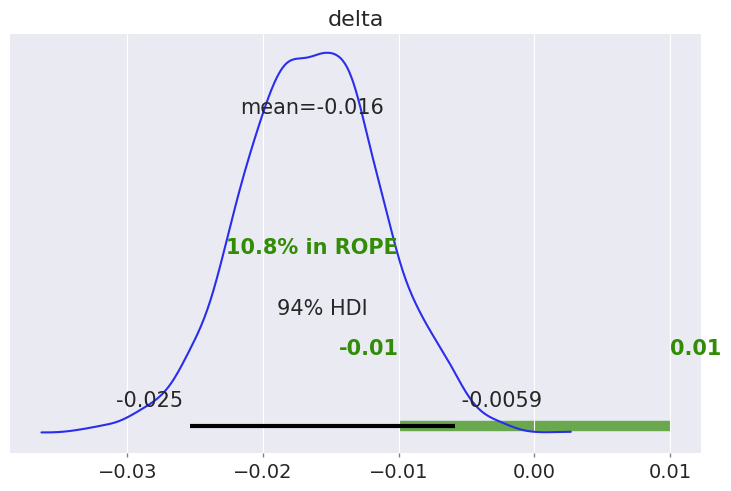

In [25]:
az.plot_posterior(
    idata_comparison,
    var_names=["delta"],
    rope=[-0.01,0.01])

plt.show()

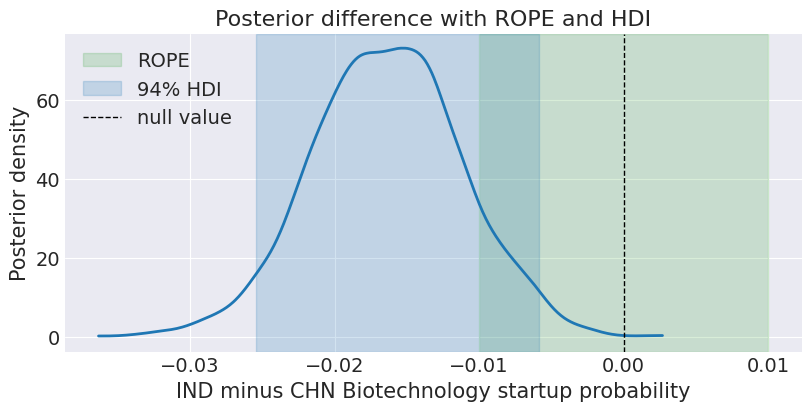

In [26]:
# ROPE + HDI plot

fig, ax = plt.subplots(figsize=(8, 4))

az.plot_kde(
    delta_samples,
    ax=ax,
    plot_kwargs={
        "color": BAYESIAN_COLOR,
        "linewidth": 2
    }
)

ax.axvspan(
    rope[0],
    rope[1],
    color=ROPE_COLOR,
    alpha=0.18,
    label="ROPE"
)

ax.axvspan(
    hdi_low,
    hdi_high,
    color=BAYESIAN_COLOR,
    alpha=0.20,
    label=f"{HDI_MASS:.0%} HDI"
)

ax.axvline(
    0,
    color=NULL_COLOR,
    linestyle="--",
    linewidth=1,
    label="null value"
)

ax.set_xlabel(f"{country_A} minus {country_B} Biotechnology startup probability")
ax.set_ylabel("Posterior density")
ax.set_title("Posterior difference with ROPE and HDI")
ax.legend()
plt.show()

### Posterior effect sizes

In [27]:
theta_A_samples = idata_comparison.posterior["theta_A"].values.ravel()
theta_B_samples = idata_comparison.posterior["theta_B"].values.ravel()

posterior_delta = theta_A_samples - theta_B_samples

posterior_risk_ratio = theta_A_samples / theta_B_samples

posterior_odds_A = theta_A_samples / (1 - theta_A_samples)
posterior_odds_B = theta_B_samples / (1 - theta_B_samples)

posterior_odds_ratio = posterior_odds_A / posterior_odds_B
posterior_log_odds_ratio = np.log(posterior_odds_ratio)

posterior_cohens_h = (
    2 * np.arcsin(np.sqrt(theta_A_samples))
    - 2 * np.arcsin(np.sqrt(theta_B_samples))
)

In [28]:
posterior_effect_size_table = pd.DataFrame({
    "effect size": [
        "Difference",
        "Risk ratio",
        "Odds ratio",
        "Log odds ratio",
        "Cohen's h"
    ],
    "posterior mean": [
        posterior_delta.mean(),
        posterior_risk_ratio.mean(),
        posterior_odds_ratio.mean(),
        posterior_log_odds_ratio.mean(),
        posterior_cohens_h.mean()
    ],
    "posterior median": [
        np.median(posterior_delta),
        np.median(posterior_risk_ratio),
        np.median(posterior_odds_ratio),
        np.median(posterior_log_odds_ratio),
        np.median(posterior_cohens_h)
    ],
    "HDI low": [
        az.hdi(posterior_delta, hdi_prob=0.94)[0],
        az.hdi(posterior_risk_ratio, hdi_prob=0.94)[0],
        az.hdi(posterior_odds_ratio, hdi_prob=0.94)[0],
        az.hdi(posterior_log_odds_ratio, hdi_prob=0.94)[0],
        az.hdi(posterior_cohens_h, hdi_prob=0.94)[0]
    ],
    "HDI high": [
        az.hdi(posterior_delta, hdi_prob=0.94)[1],
        az.hdi(posterior_risk_ratio, hdi_prob=0.94)[1],
        az.hdi(posterior_odds_ratio, hdi_prob=0.94)[1],
        az.hdi(posterior_log_odds_ratio, hdi_prob=0.94)[1],
        az.hdi(posterior_cohens_h, hdi_prob=0.94)[1]
    ],
})

display(
    posterior_effect_size_table.style.format({
        "posterior mean": "{:.4f}",
        "posterior median": "{:.4f}",
        "HDI low": "{:.4f}",
        "HDI high": "{:.4f}",
    })
)

,effect size,posterior mean,posterior median,HDI low,HDI high
0,Difference,-0.0164,-0.0163,-0.0254,-0.0059
1,Risk ratio,0.4731,0.4604,0.2550,0.6975
2,Odds ratio,0.4658,0.4527,0.2450,0.6893
3,Log odds ratio,-0.7973,-0.7925,-1.2877,-0.3155
4,Cohen's h,-0.1132,-0.1134,-0.1776,-0.0441


### Savage-Dickey / Bayes factor

,reference value,prior density at reference,posterior density at reference,BF10,BF01
0,0.0000,4.5297,0.4147,10.924,0.092


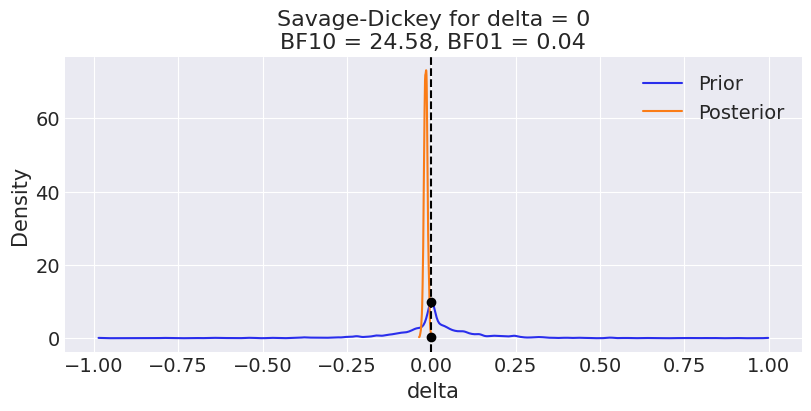

In [31]:
# Savage-Dickey compares prior density and posterior density at the reference value.
# Here the reference value is delta = 0.

reference_delta = 0

prior_delta_samples = idata_comparison.prior["delta"].values.ravel()
posterior_delta_samples = idata_comparison.posterior["delta"].values.ravel()

prior_density_at_reference = stats.gaussian_kde(prior_delta_samples)(reference_delta).item()
posterior_density_at_reference = stats.gaussian_kde(posterior_delta_samples)(reference_delta).item()

BF10 = prior_density_at_reference / posterior_density_at_reference
BF01 = posterior_density_at_reference / prior_density_at_reference

bayes_factor_summary = pd.DataFrame(
    [
        {
            "reference value": reference_delta,
            "prior density at reference": prior_density_at_reference,
            "posterior density at reference": posterior_density_at_reference,
            "BF10": BF10,
            "BF01": BF01,
        }
    ]
)

display(
    bayes_factor_summary.style.format(
        {
            "reference value": "{:.4f}",
            "prior density at reference": "{:.4f}",
            "posterior density at reference": "{:.4f}",
            "BF10": "{:.3f}",
            "BF01": "{:.3f}",
        }
    )
)


fig, ax = plt.subplots(figsize=(8, 4))

bf, ax = az.plot_bf(
    idata_comparison,
    var_name="delta",
    ref_val=reference_delta,
    ax=ax,
    show=False
)

ax.set_title(f"Savage-Dickey for delta = 0\nBF10 = {bf['BF10']:.2f}, BF01 = {bf['BF01']:.2f}")
plt.show()


## Frequentist two-proportion z test

In [48]:
# This test uses only the two selected countries.
# It does not use hierarchical information sharing.

theta_hat_A = z_A / n_A
theta_hat_B = z_B / n_B

frequentist_difference = theta_hat_A - theta_hat_B

# Under H0, both groups share one pooled probability.
pooled_null_rate = (z_A + z_B) / (n_A + n_B)

standard_error_null = np.sqrt(
    pooled_null_rate
    * (1 - pooled_null_rate)
    * (1 / n_A + 1 / n_B)
)

z_statistic = frequentist_difference / standard_error_null
two_sided_p_value = 2 * stats.norm.sf(abs(z_statistic))

reject_null = two_sided_p_value < SIGNIFICANCE_ALPHA

# Frequentist normal confidence interval for the observed difference.
# Here we use the same standard-error structure as in the lecture code.

z_critical = stats.norm.ppf(1 - SIGNIFICANCE_ALPHA / 2)

ci_low = frequentist_difference - z_critical * standard_error_null
ci_high = frequentist_difference + z_critical * standard_error_null

frequentist_test_summary = pd.DataFrame(
    [
        {
            "comparison": f"{country_A} - {country_B}",
            f"{country_A} n": n_A,
            f"{country_A} biotech": z_A,
            f"{country_A} observed rate": theta_hat_A,
            f"{country_B} n": n_B,
            f"{country_B} biotech": z_B,
            f"{country_B} observed rate": theta_hat_B,
            "observed difference": frequentist_difference,
            "pooled null rate": pooled_null_rate,
            "standard error under null": standard_error_null,
            "z statistic": z_statistic,
            "two-sided p-value": two_sided_p_value,
            f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI low": ci_low,
            f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI high": ci_high,
            f"reject at alpha={SIGNIFICANCE_ALPHA:.2f}": reject_null,
        }
    ]
)

display(
    frequentist_test_summary.style.format(
        {
            f"{country_A} observed rate": "{:.4f}",
            f"{country_B} observed rate": "{:.4f}",
            "observed difference": "{:.4f}",
            "pooled null rate": "{:.4f}",
            "standard error under null": "{:.4f}",
            "z statistic": "{:.2f}",
            "two-sided p-value": "{:.4g}",
            f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI low": "{:.4f}",
            f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI high": "{:.4f}",
        }
    )
)


,comparison,IND n,IND biotech,IND observed rate,CHN n,CHN biotech,CHN observed rate,observed difference,pooled null rate,standard error under null,z statistic,two-sided p-value,95% normal CI low,95% normal CI high,reject at alpha=0.05
0,IND - CHN,1596,22,0.0138,1544,47,0.0304,-0.0167,0.0220,0.0052,-3.18,0.001459,-0.0269,-0.0064,True


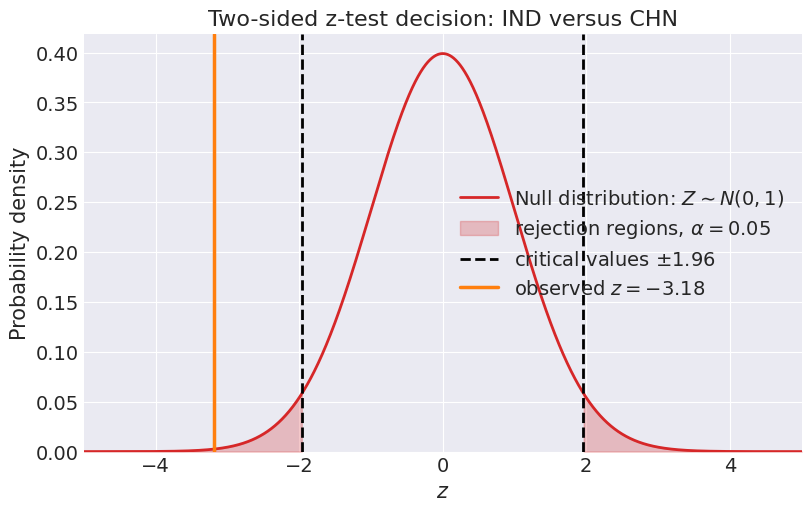

In [57]:
# Plot the null distribution, critical z values, and observed z statistic

standard_normal_x = np.linspace(-5, 5, 2000)
standard_normal_pdf = stats.norm.pdf(standard_normal_x)

z_observed = z_statistic
z_critical = stats.norm.ppf(1 - SIGNIFICANCE_ALPHA / 2)

fig, ax = plt.subplots(figsize=(8, 5))

# Null distribution
ax.plot(
    standard_normal_x,
    standard_normal_pdf,
    color=FREQUENTIST_COLOR,
    linewidth=2,
    label=r"Null distribution: $Z \sim N(0,1)$"
)

# Critical regions
left_rejection_region = standard_normal_x <= -z_critical
right_rejection_region = standard_normal_x >= z_critical

ax.fill_between(
    standard_normal_x[left_rejection_region],
    0,
    standard_normal_pdf[left_rejection_region],
    color=FREQUENTIST_COLOR,
    alpha=0.25,
    label=rf"rejection regions, $\alpha={SIGNIFICANCE_ALPHA}$"
)

ax.fill_between(
    standard_normal_x[right_rejection_region],
    0,
    standard_normal_pdf[right_rejection_region],
    color=FREQUENTIST_COLOR,
    alpha=0.25
)

# Critical z values
ax.axvline(
    -z_critical,
    color="black",
    linestyle="--",
    linewidth=2,
    label=rf"critical values $\pm {z_critical:.2f}$"
)

ax.axvline(
    z_critical,
    color="black",
    linestyle="--",
    linewidth=2
)

# Observed z statistic
ax.axvline(
    z_observed,
    color="tab:orange",
    linewidth=2.5,
    label=rf"observed $z = {z_observed:.2f}$"
)

ax.set_title(f"Two-sided z-test decision: {country_A} versus {country_B}")
ax.set_xlabel(r"$z$")
ax.set_ylabel("Probability density")
ax.set_xlim(-5, 5)
ax.set_ylim(bottom=0)
ax.legend()
plt.show()

### Power analysis using simulation

In [35]:
# We use a frequentist two-sided z-test decision rule.
# Power is the proportion of simulated datasets in which the test rejects H0.

POWER_TARGET = 0.80
POWER_NUM_REPS = 5000
POWER_SEED = 817_143

power_rng = np.random.default_rng(POWER_SEED)

# Use the observed effect as an example effect size for simulation.
# For teaching, this can also be replaced by a minimal meaningful effect.
baseline_rate = min(rate_A, rate_B)
effect_for_power = abs(observed_difference)

# Keep probabilities inside [0, 1].
true_rate_low = baseline_rate
true_rate_high = min(baseline_rate + effect_for_power, 0.999)

print(f"Power simulation low true rate: {true_rate_low:.4f}")
print(f"Power simulation high true rate: {true_rate_high:.4f}")
print(f"Effect used for power simulation: {true_rate_high - true_rate_low:.4f}")


Power simulation low true rate: 0.0138
Power simulation high true rate: 0.0304
Effect used for power simulation: 0.0167


In [36]:
def two_proportion_z_test_from_counts(z1, n1, z2, n2, alpha=0.05):
    """
    Two-sided two-proportion z test using the normal approximation.

    z1, z2 can be scalars or NumPy arrays.
    """

    theta1_hat = z1 / n1
    theta2_hat = z2 / n2

    difference_hat = theta1_hat - theta2_hat

    pooled_rate = (z1 + z2) / (n1 + n2)

    standard_error = np.sqrt(
        pooled_rate
        * (1 - pooled_rate)
        * (1 / n1 + 1 / n2)
    )

    z_stat = difference_hat / standard_error
    p_value = 2 * stats.norm.sf(np.abs(z_stat))

    rejected = p_value < alpha

    return z_stat, p_value, rejected


def estimate_power_for_group_size(
    n_per_group,
    true_rate_low,
    true_rate_high,
    num_reps=5000,
    alpha=0.05,
    rng=None
):
    """
    Estimate power for a two-sided two-proportion z test.
    """

    if rng is None:
        rng = np.random.default_rng()

    simulated_z_low = rng.binomial(
        n=n_per_group,
        p=true_rate_low,
        size=num_reps
    )

    simulated_z_high = rng.binomial(
        n=n_per_group,
        p=true_rate_high,
        size=num_reps
    )

    _, _, rejected = two_proportion_z_test_from_counts(
        z1=simulated_z_high,
        n1=n_per_group,
        z2=simulated_z_low,
        n2=n_per_group,
        alpha=alpha
    )

    return rejected.mean()


/tmp/ipykernel_413/2602297290.py:21: RuntimeWarning: invalid value encountered in divide
  z_stat = difference_hat / standard_error


,planned n per group,estimated power
0,50,0.035
1,100,0.113
2,150,0.151
3,200,0.187
4,300,0.283
5,500,0.437
6,750,0.614
7,1000,0.726
8,1500,0.879
9,2000,0.956


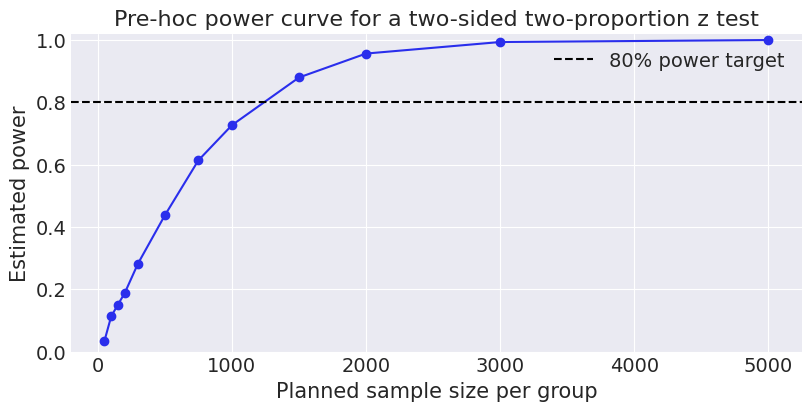

In [37]:
planned_group_sizes = np.array([
    50, 100, 150, 200, 300, 500, 750, 1000,
    1500, 2000, 3000, 5000
])

power_values = []

for n_planned in planned_group_sizes:
    power_estimate = estimate_power_for_group_size(
        n_per_group=n_planned,
        true_rate_low=true_rate_low,
        true_rate_high=true_rate_high,
        num_reps=POWER_NUM_REPS,
        alpha=SIGNIFICANCE_ALPHA,
        rng=power_rng
    )

    power_values.append(power_estimate)

power_table = pd.DataFrame({
    "planned n per group": planned_group_sizes,
    "estimated power": power_values
})

display(
    power_table.style.format(
        {
            "estimated power": "{:.3f}"
        }
    )
)


fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    power_table["planned n per group"],
    power_table["estimated power"],
    marker="o"
)

ax.axhline(
    POWER_TARGET,
    color="black",
    linestyle="--",
    label=f"{POWER_TARGET:.0%} power target"
)

ax.set_xlabel("Planned sample size per group")
ax.set_ylabel("Estimated power")
ax.set_title("Pre-hoc power curve for a two-sided two-proportion z test")
ax.set_ylim(0, 1.02)
ax.legend()
plt.show()

### Post-hoc Power calculation

### Final summary table

In [ ]:
if reject_null:
    frequentist_decision = "Reject H0"
else:
    frequentist_decision = "Fail to reject H0"

summary_table = pd.DataFrame(
    [
        {
            "analysis": "Observed data",
            "quantity": "Observed difference",
            "result": observed_difference,
            "interpretation": "Raw effect size in the observed data",
        },
        {
            "analysis": "Bayesian hierarchical model",
            "quantity": "Posterior mean of delta",
            "result": delta_mean,
            "interpretation": "Model-based difference after partial pooling",
        },
        {
            "analysis": "Bayesian hierarchical model",
            "quantity": f"{HDI_MASS:.0%} HDI",
            "result": f"[{hdi_low:.4f}, {hdi_high:.4f}]",
            "interpretation": "Posterior uncertainty for delta",
        },
        {
            "analysis": "Bayesian ROPE/HDI test",
            "quantity": "ROPE decision",
            "result": rope_decision,
            "interpretation": "Practical-null decision under the Bayesian model",
        },
        {
            "analysis": "Savage-Dickey",
            "quantity": "BF10",
            "result": BF10,
            "interpretation": "Evidence against delta = 0 relative to the prior",
        },
        {
            "analysis": "Frequentist z test",
            "quantity": "z statistic",
            "result": z_statistic,
            "interpretation": "Statistic under the null sampling distribution",
        },
        {
            "analysis": "Frequentist z test",
            "quantity": "two-sided p-value",
            "result": two_sided_p_value,
            "interpretation": frequentist_decision,
        },
        {
            "analysis": "Frequentist confidence interval",
            "quantity": f"{(1 - SIGNIFICANCE_ALPHA):.0%} normal CI",
            "result": f"[{ci_low:.4f}, {ci_high:.4f}]",
            "interpretation": "Interval from the frequentist normal approximation",
        },
    ]
)

display(summary_table)


### Reporting template (use if you like)

In [ ]:
print(f"""
Statistical report template

The observed Biotechnology startup rate was {rate_A:.3f} in {country_A}
and {rate_B:.3f} in {country_B}. The observed difference was
{observed_difference:.3f}.

Under the hierarchical Bayesian model, the posterior mean difference
({country_A} - {country_B}) was {delta_mean:.3f}, with a {HDI_MASS:.0%}
HDI from {hdi_low:.3f} to {hdi_high:.3f}. The posterior probability that
the difference is positive was {prob_delta_positive:.3f}. The ROPE/HDI
decision was: {rope_decision}.

The frequentist two-sided two-proportion z test gave z = {z_statistic:.2f}
and p = {two_sided_p_value:.4g}. Therefore, using alpha = {SIGNIFICANCE_ALPHA:.2f},
we {frequentist_decision.lower()}.

The Bayesian result is a hierarchical model-based comparison after information
sharing between countries. The frequentist result is an independent two-country
normal-approximation test using only the selected countries.
""")